# Analyse du model et interpretation des resultats

In [17]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [19]:
from pyspark.ml.pipeline import PipelineModel

best_model = PipelineModel.load("final_accident_model")

In [20]:
log_reg_model = best_model.stages[-1]

In [22]:
coefficients = log_reg_model.coefficientMatrix
intercept = log_reg_model.interceptVector

In [24]:
from pyspark.ml.feature import VectorAssembler

vector_assembler = [stage for stage in best_model.stages if isinstance(stage, VectorAssembler)][0]
input_features = vector_assembler.getInputCols()

In [27]:
from pyspark.ml.feature import OneHotEncoder, StringIndexerModel

# Si tu as utilisé OneHotEncoder, tu peux reconstituer les noms des colonnes finales comme suit (approximatif)
# Pour un résultat très précis, tu peux exporter les features avec `vectorAssembler.getInputCols()` 
# et croiser avec l'encodage

feature_names = []
for feature in input_features:
    if isinstance(feature, StringIndexerModel):
        feature_names.append(feature.getOutputCol())
    elif isinstance(feature, OneHotEncoder):
        feature_names.extend(feature.getOutputCols())
    else:
        feature_names.append(feature)


In [33]:
import pandas as pd

# Only show the coefficients, since feature_names does not match the number of coefficients
df_coeffs = pd.DataFrame({
    "Coefficient": coefficients.toArray()[class_idx]
}).sort_values(by="Coefficient", ascending=False)

/tmp/ipykernel_1838/686826398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_coeffs_plot, x="Coefficient", y="Feature", palette="coolwarm")


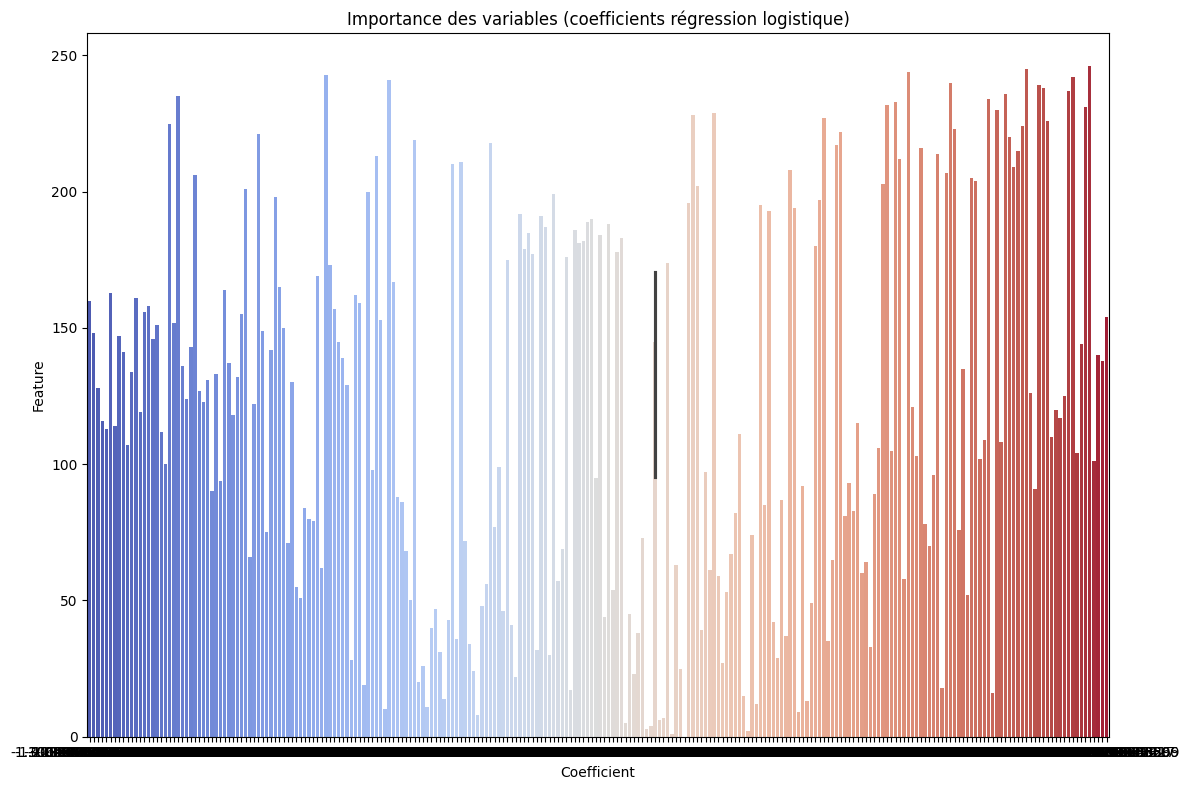

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

df_coeffs_plot = df_coeffs.reset_index().rename(columns={"index": "Feature"})

plt.figure(figsize=(12, 8))
sns.barplot(data=df_coeffs_plot, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Importance des variables (coefficients régression logistique)")
plt.tight_layout()
plt.show()
